In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import torch
import networkx as nx
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator
from scipy.signal import argrelextrema
from scipy.stats import gaussian_kde

In [ ]:
# --- 0.解析パラメータ設定 (一括管理) ---
# 画像パスとモデルパスの設定
image_path = "images/pyramid2_test.jpeg" # 自身の環境に合わせて変更してください
checkpoint_path = "sam_vit_b_01ec64.pth" # 自身の環境に合わせて変更してください



# --- 1. SAMと可視化のための関数 ---

def show_anns(anns):
    #「SAMが出力したアノテーション（マスク情報）を画像上に可視化する関数」
    #  具体的な処理:入力されたマスクデータ anns を、面積が大きい順に並べ替えます（小さい石が大きい石に隠れるのを防ぐため）。
    # plt.gca() で現在のプロット領域を取得し、半透明のカラーマスク（RGBA形式）を作成します。
    # 目的: SAMが正しく石を認識できているかを目視で確認するために使用します。
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)
    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:,:,3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.35]])
        img[m] = color_mask
    ax.imshow(img)

def process_with_sam(image_path, model_checkpoint):
    # 機能: AIモデル（Segment Anything Model）をロードし、画像に対してセグメンテーションを実行する関数。
    # 具体的な処理:
    # 指定された画像ファイル（image_path）を読み込みます。
    # 計算リソース（GPU/CPU）を自動判定します。
    # sam_model_registry を用いてモデルを初期化し、SamAutomaticMaskGenerator を作成します。
    # mask_generator.generate(image) を実行し、画像内の全物体に対するマスク生成を行います。
    # 目的: 画像解析の中核となる処理であり、生の画像データから石の領域を自動抽出します。
    print("--- SAM解析開始 ---")
    image = cv2.imread(image_path)
    if image is None:
        print(f"エラー: 画像が見つかりません: {image_path}")
        return None
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    device = "cuda" if torch.cuda.is_available() else "cpu"


    model_type = "vit_b"
    sam = sam_model_registry[model_type](checkpoint=model_checkpoint)
    sam.to(device=device)

    mask_generator = SamAutomaticMaskGenerator(sam)

    # 旧
    # mask_generator = SamAutomaticMaskGenerator(
    #     model=sam,
    #     points_per_side=32,
    #     pred_iou_thresh=0.86,
    #     stability_score_thresh=0.92,
    #     crop_n_layers=0,
    #     crop_n_points_downscale_factor=1,
    #     min_mask_region_area=100,
    # )
    
    print("セグメンテーション実行中...")
    masks = mask_generator.generate(image)
    print(f"検出された石（領域）の数: {len(masks)}")
    
    return masks


# def save_masks_to_csv(masks):#未確認
#     data = []
#     for i, mask_data in enumerate(masks):
#         # バウンディングボックスと重心の計算
#         segmentation = mask_data['segmentation']
#         y_indices, x_indices = np.where(segmentation)
        
#         if len(y_indices) == 0 or len(x_indices) == 0:
#             continue # 空のマスクはスキップ
            
#         centroid_y = np.mean(y_indices)
#         centroid_x = np.mean(x_indices)
#         area = mask_data['area']
        
#         # IDは1から始める
#         data.append({
#             'Stone_ID': i + 1,
#             'Centroid_X': centroid_x,
#             'Centroid_Y': centroid_y,
#             'Area': area
#         })
    
#     df = pd.DataFrame(data)
#     return df

def sort_masks_bottom_up(masks): #いる
    # bbox[1] (y座標) が大きい順 ＝ 画像の下にある順
    return sorted(masks, key=lambda x: x['bbox'][1], reverse=True)



def visualize_labeled_masks(image, masks, title="Labeled Stones"):#未確認
    vis_img = image.copy()
    overlay = vis_img.copy()
    font = cv2.FONT_HERSHEY_SIMPLEX
    
    for i, mask in enumerate(masks):
        idx = i + 1
        y_indices, x_indices = np.where(mask['segmentation'])
        if len(y_indices) == 0: continue
        center_y = int(np.mean(y_indices))
        center_x = int(np.mean(x_indices))
        
        color = np.random.randint(0, 255, (3,)).tolist()
        overlay[mask['segmentation']] = color
        
        text = str(idx)
        cv2.putText(vis_img, text, (center_x-10, center_y+10), font, 0.6, (255, 255, 255), 2)

    cv2.addWeighted(overlay, 0.4, vis_img, 0.6, 0, vis_img)
    plt.figure(figsize=(10, 10))
    plt.imshow(vis_img)
    plt.title(title)
    plt.axis('off')
    plt.show()


def main():
    # 2-1. SAM実行
    masks = process_with_sam(image_path, checkpoint_path)
    if masks is None:
        return None, None

    # 画像再読み込み（可視化用）
    image_bgr = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    # 2-2. 対話的修正ループ
    current_masks = sort_masks_bottom_up(masks)
    
    while True:
        visualize_labeled_masks(image_rgb, current_masks, title=f"Check: {len(current_masks)} stones")
        print("【修正モード】削除したい石の番号をスペース区切りで入力（例: '3 5'）。完了ならEnter。")
        user_input = input("削除番号 >> ")
        
        if not user_input.strip():
            break
        
        try:
            remove_ids = set(map(int, user_input.split()))
            new_masks = [m for i, m in enumerate(current_masks) if (i + 1) not in remove_ids]
            current_masks = new_masks
            if len(current_masks) == 0: break
        except ValueError:
            print("数値を入力してください。")

    # 2-3. データフレームの作成（これが抜けていたため追加）
    print("データフレームを作成中...")
    data_list = []
    for i, m in enumerate(current_masks):
        data_list.append({
            'Stone_ID': i + 1,
            'Area': m['area'],
            'bbox': m['bbox'] # 後の処理で使うため保存
        })
    df = pd.DataFrame(data_list)

    print("メイン処理完了。データを返却します。")
    # ★重要: ここで変数を外に返す
    return current_masks, df
    

#--------------------------------------------------------------------------------

#  構造石ベースの段推定 (ここまでフェーズ1ですることにした)(図×2の出力まで)
def add_structural_tiering_v4(masks, df_stones, area_threshold_ratio=1.1):
    """
    構造石（大きな石）の分布から段の境界を決定し、全石を分類する
    """
    # 1. 重心の計算
    centroids_y = []
    centroids_x = []
    for m in masks:
        x, y, w, h = m['bbox']
        centroids_y.append(y + h / 2)
        centroids_x.append(x + w / 2)
    
    df_stones['Centroid_X'] = centroids_x
    df_stones['Centroid_Y'] = centroids_y

    # 2. 構造石(Structural Stones)の特定
    avg_area = df_stones['Area'].mean()
    df_stones['is_structural'] = df_stones['Area'] > (avg_area * area_threshold_ratio)
    
    structural_stones = df_stones[df_stones['is_structural']]
    structural_ids = structural_stones['Stone_ID'].tolist()
    
    print(f"\n[確認] 基準となる構造石の数: {len(structural_ids)}")
    print(f"[確認] 構造石Fsaveのラベル番号: {structural_ids}")

    # 3. 構造石のY座標のみを用いてKDE（密度解析）を実行
    y_values_struct = structural_stones['Centroid_Y'].values
    
    # 帯域幅(bw_method)を調整することで感度を変えられます
    kde = gaussian_kde(y_values_struct, bw_method=0.15) 
    y_grid = np.linspace(df_stones['Centroid_Y'].min()-50, df_stones['Centroid_Y'].max()+50, 1000)
    y_density = kde(y_grid)
    
    # 密度の「谷」を境界線として取得
    valleys_indices = argrelextrema(y_density, np.less, order=10)[0]
    boundaries = sorted([-np.inf] + list(y_grid[valleys_indices]) + [np.inf])
    
    # 4. 全ての石（構造石 + 破片）を境界線に基づいてグルーピング
    df_stones['Tier_Group'] = pd.cut(df_stones['Centroid_Y'], bins=boundaries, labels=False)
    
    # Y座標が大きい（画像の下）ほど若い段数になるようリラベル
    unique_tiers = sorted(df_stones['Tier_Group'].unique(), reverse=True)
    tier_map = {original: i+1 for i, original in enumerate(unique_tiers)}
    df_stones['Tier'] = df_stones['Tier_Group'].map(tier_map)
    
    # 不要なカラムの削除
    df_stones.drop(columns=['Tier_Group'], inplace=True)
    
    return df_stones, y_grid, y_density, boundaries




--- SAM解析開始 ---
セグメンテーション実行中...
検出された石（領域）の数: 77


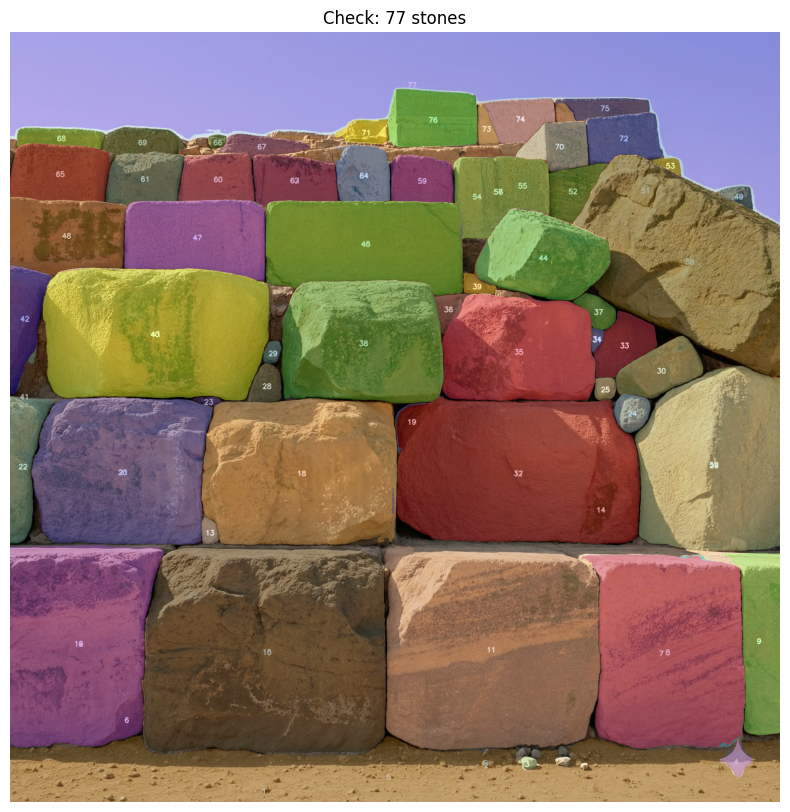

【修正モード】削除したい石の番号をスペース区切りで入力（例: '3 5'）。完了ならEnter。


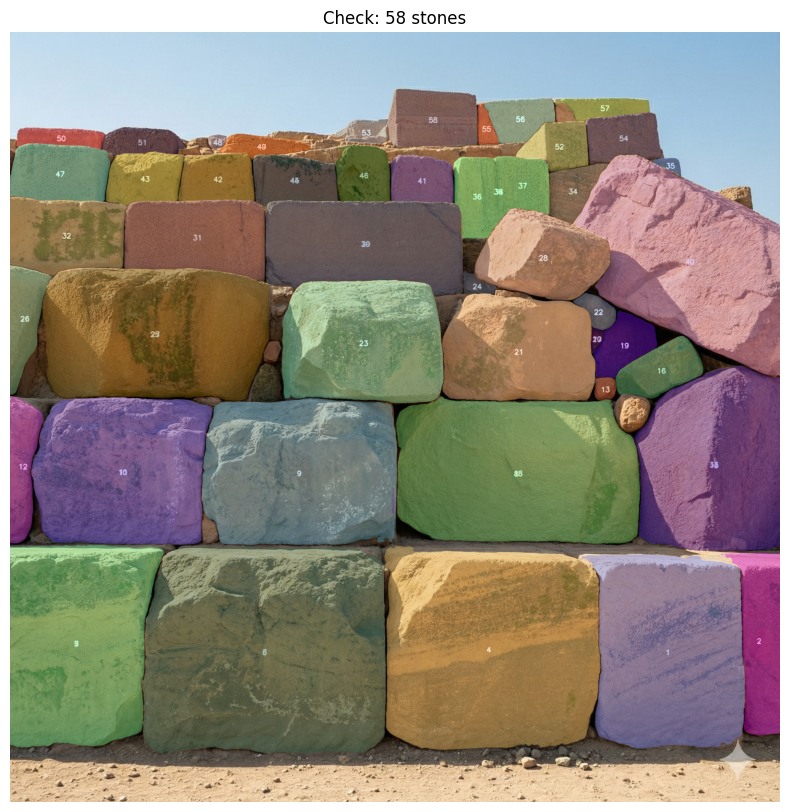

【修正モード】削除したい石の番号をスペース区切りで入力（例: '3 5'）。完了ならEnter。


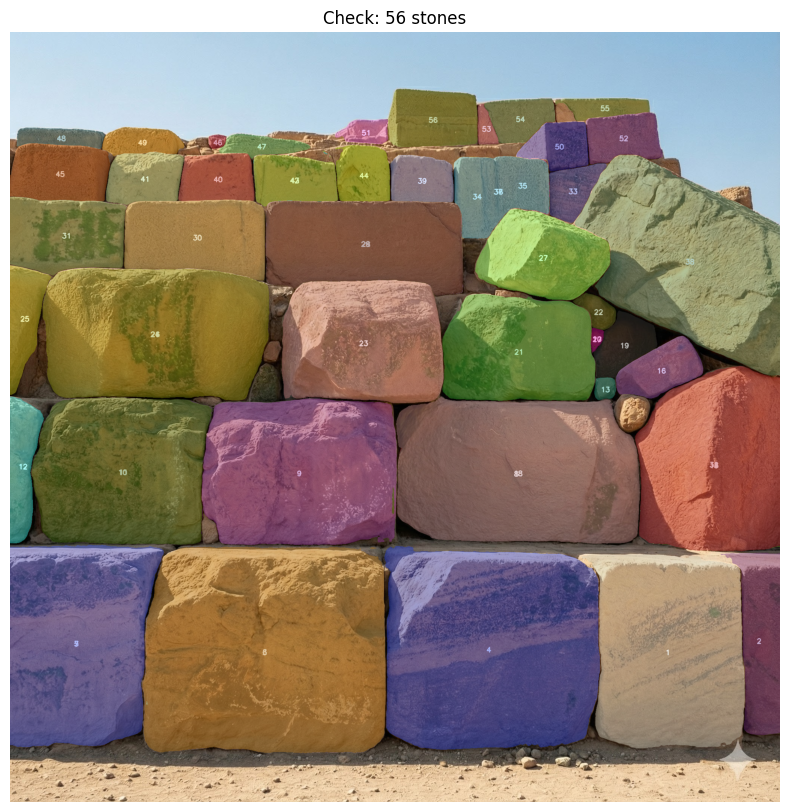

【修正モード】削除したい石の番号をスペース区切りで入力（例: '3 5'）。完了ならEnter。
データフレームを作成中...
メイン処理完了。データを返却します。

[確認] 基準となる構造石の数: 21
[確認] 構造石Fsaveのラベル番号: [1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 14, 15, 18, 21, 23, 24, 26, 28, 29, 32, 38]

--- ティア別解析結果 ---
Tier
1     5
2     3
3     7
4    12
5    29
Name: count, dtype: int64


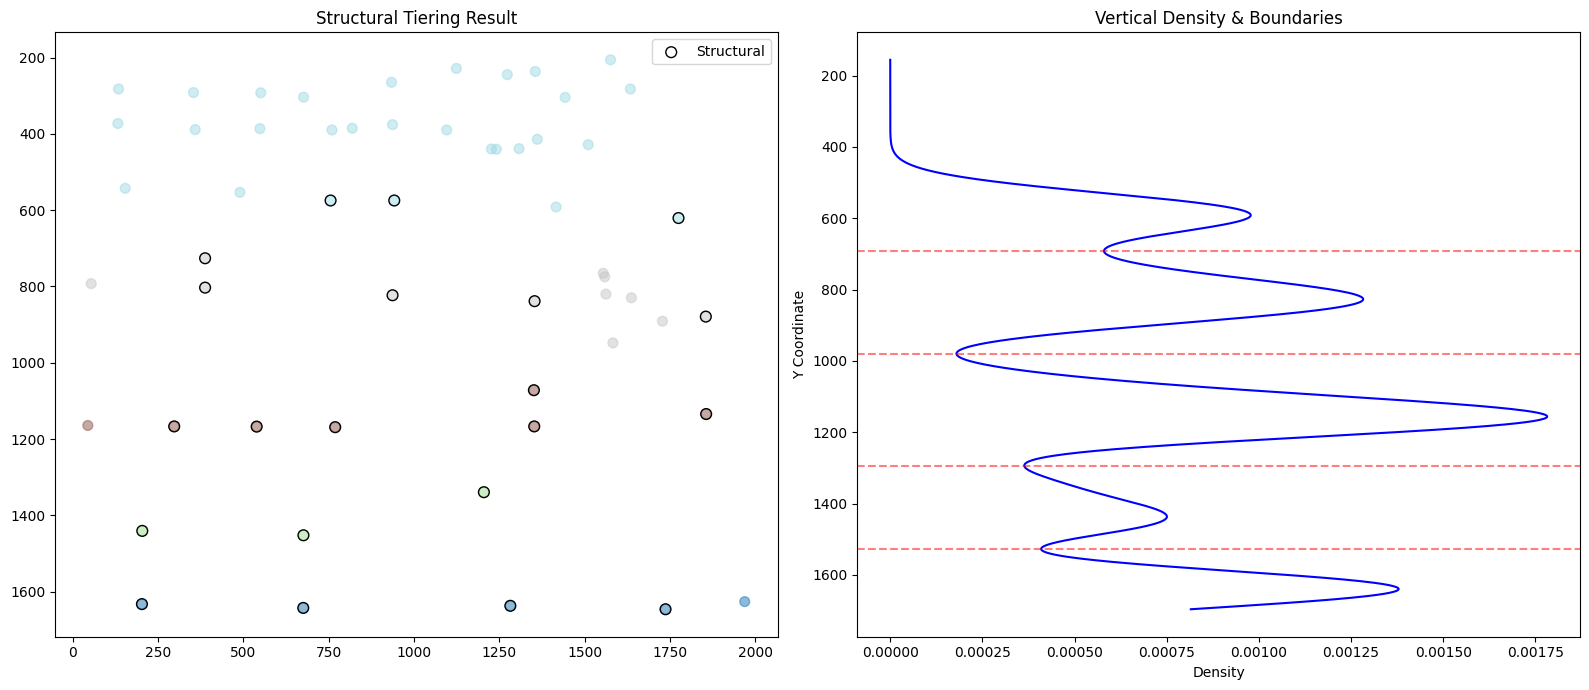

In [15]:
# --- 実行ブロック ---
if __name__ == "__main__":
    # main関数から最新のデータを取得
    # ※ current_masks, df がメモリにある場合は main() を飛ばしてOK
    current_masks, df = main() 

    if current_masks is not None:
        # 構造石ベースのティアリングを実行
        df, y_grid, y_density, boundaries = add_structural_tiering_v4(current_masks, df)
        
        # 結果の統計表示
        print("\n--- ティア別解析結果 ---")
        tier_counts = df['Tier'].value_counts().sort_index()
        print(tier_counts)

        # 可視化（test_3のスタイルを継承）
        fig, ax = plt.subplots(1, 2, figsize=(16, 7))

        # 左：空間プロット（段ごとに色分け）
        ax[0].invert_yaxis()
        # 全石を表示
        scatter = ax[0].scatter(df['Centroid_X'], df['Centroid_Y'], c=df['Tier'], cmap='tab20', s=50, alpha=0.5)
        # 構造石のみ枠線を付けて強調
        struct_df = df[df['is_structural']]
        ax[0].scatter(struct_df['Centroid_X'], struct_df['Centroid_Y'], c='none', edgecolors='black', s=60, label='Structural')
        
        ax[0].set_title("Structural Tiering Result")
        ax[0].legend()

        # 右：KDEグラフ（どこで区切ったかを確認）
        ax[1].plot(y_density, y_grid, color='blue', label='Structural Density')
        for b in boundaries:
            if b not in [np.inf, -np.inf]:
                ax[1].axhline(y=b, color='red', linestyle='--', alpha=0.5)
        ax[1].invert_yaxis()
        ax[1].set_title("Vertical Density & Boundaries")
        ax[1].set_xlabel("Density")
        ax[1].set_ylabel("Y Coordinate")

        plt.tight_layout()
        plt.show()


In [18]:
#フェーズ2 主に最終的なグラフ構造化

# (旧に合った)段(Tier)の推定フェーズ
#一応この関数なくても、新しいコードは動いてたけど(旧には必要だった)、ここで何が起こっているか、結果にどう反映されているかはチェック必要だぞ

def analyze_horizontal_order_v4(df_stones, masks, dilate_px=10):#新しいのにはない！
    """
    df_stonesとmasksが1対1で対応していることを前提に、
    安全にインデックスを管理して隣接グラフを構築する。
    """
    print("\n--- 水平方向の解析（インデックス同期版）開始 ---")
    
    # 1. データフレームのインデックスを振り直し、マスクとの順序を固定する
    # main()から返された直後であれば、df_stonesのi行目はmasksのi番目に対応している
    df_working = df_stones.copy().reset_index(drop=True)
    
    # 2. 垂直方向の段(Tier)でグループ化した後、各段の中で左から順に並べる
    # 注意: ここでソートするとmasksとの順序が崩れるため、
    # masksの元の位置を保持するための 'original_idx' を作っておく
    df_working['original_idx'] = df_working.index 
    
    # 段(Tier) -> X座標 の順でソートして順位を決定
    df_sorted = df_working.sort_values(['Tier', 'Centroid_X']).copy()
    df_sorted['Horizontal_Rank'] = df_sorted.groupby('Tier').cumcount() + 1
    
    # 3. 隣接グラフの構築
    G = nx.Graph()
    for idx, row in df_sorted.iterrows():
        # 描画用に Stone_ID をノード名にする
        G.add_node(row['Stone_ID'], pos=(row['Centroid_X'], row['Centroid_Y']), 
                   tier=row['Tier'], rank=row['Horizontal_Rank'])

    # 4. 隣接判定（元のインデックスを使用してマスクにアクセス）
    print(f"隣接関係を計算中... (対象石数: {len(df_sorted)})")
    
    # 効率のため、一度全マスクを膨張させたものをリスト化する
    dilated_masks = []
    kernel = np.ones((dilate_px, dilate_px), np.uint8)
    for i in range(len(df_working)):
        m = masks[i]['segmentation'].astype(np.uint8)
        dilated_masks.append(cv2.dilate(m, kernel, iterations=1))

    # 二重ループで接触判定
    stone_rows = [row for _, row in df_sorted.iterrows()]
    for i in range(len(stone_rows)):
        row_i = stone_rows[i]
        idx_i = int(row_i['original_idx']) # 元のリスト位置
        id_i = row_i['Stone_ID']
        
        for j in range(i + 1, len(stone_rows)):
            row_j = stone_rows[j]
            idx_j = int(row_j['original_idx']) # 元のリスト位置
            id_j = row_j['Stone_ID']
            
            # 膨張させたマスクiと、通常のマスクjの重なりをチェック
            if np.any(np.logical_and(dilated_masks[idx_i], masks[idx_j]['segmentation'])):
                G.add_edge(id_i, id_j)
                

    return df_sorted, G


#-----------------------------------------------------------------------


DEFAULT_DILATE_PX = 10 
DEFAULT_Y_THRESHOLD = 40

#新しい方
def analyze_tiering_bottom_up(df_stones, masks, y_threshold=DEFAULT_Y_THRESHOLD, dilate_px=DEFAULT_DILATE_PX):
    
    print("\n--- ボトムアップ・チェイン法（隣接エッジ構築）開始 ---")
    
    df_work = df_stones.copy()
    df_work['Tier'] = -1
    # 元のリスト順序を保持（IndexError対策）
    df_work['mask_index'] = df_stones.index 
    df_work = df_work.sort_values('Centroid_Y', ascending=False)
    
    # 隣接グラフの初期化
    G = nx.Graph()
    for _, row in df_stones.iterrows():
        G.add_node(row['Stone_ID'], pos=(row['Centroid_X'], row['Centroid_Y']))
    
    current_tier = 1
    processed_indices = set()
    
    for i in range(len(df_work)):
        target_idx = df_work.index[i]
        if target_idx in processed_indices:
            continue
            
        queue = [target_idx]
        processed_indices.add(target_idx)
        df_work.at[target_idx, 'Tier'] = current_tier
        
        q_idx = 0
        while q_idx < len(queue):
            curr_idx = queue[q_idx]
            q_idx += 1
            curr_row = df_work.loc[curr_idx]
            
            m_idx_i = int(curr_row['mask_index'])
            mask_i = masks[m_idx_i]['segmentation'].astype(np.uint8)
            dilated_i = cv2.dilate(mask_i, np.ones((dilate_px, dilate_px), np.uint8), iterations=1)
            
            for other_idx in df_work.index:
                if other_idx == curr_idx: continue
                
                other_row = df_work.loc[other_idx]
                
                # 同一段の条件：高さが近く、かつ物理的に接触している
                if abs(curr_row['Centroid_Y'] - other_row['Centroid_Y']) < y_threshold:
                    m_idx_j = int(other_row['mask_index'])
                    if np.any(np.logical_and(dilated_i, masks[m_idx_j]['segmentation'])):
                        # グラフにエッジを追加
                        G.add_edge(curr_row['Stone_ID'], other_row['Stone_ID'])
                        
                        if other_idx not in processed_indices:
                            df_work.at[other_idx, 'Tier'] = current_tier
                            processed_indices.add(other_idx)
                            queue.append(other_idx)
        current_tier += 1
    
    # 正規化とランク付け
    unique_tiers = sorted(df_work['Tier'].unique(), reverse=True)
    tier_map = {old: new + 1 for new, old in enumerate(unique_tiers)}
    df_work['Tier'] = df_work['Tier'].map(tier_map)
    
    df_work = df_work.sort_values(['Tier', 'Centroid_X'])
    df_work['Horizontal_Rank'] = df_work.groupby('Tier').cumcount() + 1
    
    print(f"推定完了: {df_work['Tier'].max()} 段を検出しました。")
    return df_work, G


#多分コードから推測するに描画グラフはこれ以前に完成していて、描画に関するコード
def visualize_bottom_up(image_rgb, df_stones, G_tier=None, font_size=24):
    """
    結果の可視化（文字強調版：黒色・太字・サイズ2倍）
    """
    fig, ax = plt.subplots(figsize=(20, 14))
    ax.imshow(image_rgb)
    
    if 'Horizontal_Rank' not in df_stones.columns:
         df_stones = df_stones.sort_values(['Tier', 'Centroid_X'])
         df_stones['Horizontal_Rank'] = df_stones.groupby('Tier').cumcount() + 1
    
    # エッジ（白い線）があれば描画
    if G_tier is not None:
         pos = nx.get_node_attributes(G_tier, 'pos')
         nx.draw_networkx_edges(G_tier, pos, ax=ax, alpha=0.4, edge_color='white', width=1.5)

    for _, row in df_stones.iterrows():
        color = plt.cm.get_cmap('tab20')(int(row['Tier']) % 20)
        
        
        radius = font_size * 1.5# 文字を大きくするため、背景の円も大きくします
        
        circle = plt.Circle((row['Centroid_X'], row['Centroid_Y']), radius, 
                            color=color, ec='black', lw=2, alpha=0.7, zorder=5)
        ax.add_patch(circle)

        # ちなみに旧は
        # color = plt.cm.tab20(int(row['Tier']) % 20)
        # radius = 16 * base_scale * node_scale
        # circle = plt.Circle((row['Centroid_X'], row['Centroid_Y']), radius, 
        #                     color=color, ec='white', lw=1, alpha=0.8, zorder=5)
        # ax.add_patch(circle)やった
        # 多分そんな変わらん
        
        ax.text(row['Centroid_X'], row['Centroid_Y'], str(int(row['Horizontal_Rank'])), 
                color='black',
                ha='center', va='center', 
                fontsize=font_size * 2,
                fontweight='bold',
                zorder=6)

    plt.title("Bottom-up Chain Tiering Result", fontsize=15)#旧やと Final Construction Analysis: Vertical Tiers & Horizontal Sequence
    plt.axis('off')
    #plt.tight_layout() tightである必要があるのか
    plt.show()



##こっからはただの結果の出力まとめ編
def print_analysis_summary(df_results):
    print("========================================")
    print("          ピラミッド解析サマリー         ")
    print("========================================")
    
    total_stones = len(df_results)
    tiers = sorted(df_results['Tier'].unique(), reverse=True)
    total_tiers = len(tiers)
    
    print(f"■ 認識された石の総数 : {total_stones} 個")
    print(f"■ 認識された総段数   : {total_tiers} 段")
    print("-" * 40)
    
    print("■ 各段の石の配列（左から右）")
    for t in tiers:
        tier_stones = df_results[df_results['Tier'] == t].sort_values('Horizontal_Rank')
        stone_ids = tier_stones['Stone_ID'].astype(int).astype(str).tolist()
        tier_line = " - ".join(stone_ids)
        print(f"Tier {int(t):>2} : {tier_line}")
    print("========================================\n")



def search_stone_info(target_id, df_results, masks, dilate_px=DEFAULT_DILATE_PX):
    stone_data = df_results[df_results['Stone_ID'] == target_id]
    
    if stone_data.empty:
        print(f"× 石番号 {target_id} は見つかりません。")
        return

    row = stone_data.iloc[0]
    m_idx = int(row['mask_index'])
    
    print(f"【石番号 {target_id} の詳細解析データ】")
    print(f"----------------------------------------")
    print(f"・面積         : {row['Area']:.2f} px²")
    print(f"・推定位置     : {int(row['Tier'])} 段目の {int(row['Horizontal_Rank'])} 番目 (左から)")
    print(f"・重心座標     : (X: {row['Centroid_X']:.1f}, Y: {row['Centroid_Y']:.1f})")
    
    mask_i = masks[m_idx]['segmentation'].astype(np.uint8)
    kernel = np.ones((dilate_px, dilate_px), np.uint8)
    dilated_i = cv2.dilate(mask_i, kernel, iterations=1)
    
    adj_lr = []
    adj_ud = []
    
    my_tier = row['Tier']
    
    for _, other in df_results.iterrows():
        if other['Stone_ID'] == target_id: continue
        
        m_idx_j = int(other['mask_index'])
        if np.any(np.logical_and(dilated_i, masks[m_idx_j]['segmentation'])):
            other_id = int(other['Stone_ID'])
            if other['Tier'] == my_tier:
                adj_lr.append(other_id)
            else:
                adj_ud.append(other_id)
                
    print(f"・隣接（左右） : {adj_lr if adj_lr else 'なし'}")
    print(f"・隣接（上下） : {adj_ud if adj_ud else 'なし'}")
    print(f"----------------------------------------")


--- ボトムアップ・チェイン法（隣接エッジ構築）開始 ---
推定完了: 20 段を検出しました。


/var/folders/p1/y3txcf3s2wq_l30gfj6xb62r0000gn/T/ipykernel_55516/1819359687.py:155: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color = plt.cm.get_cmap('tab20')(int(row['Tier']) % 20)


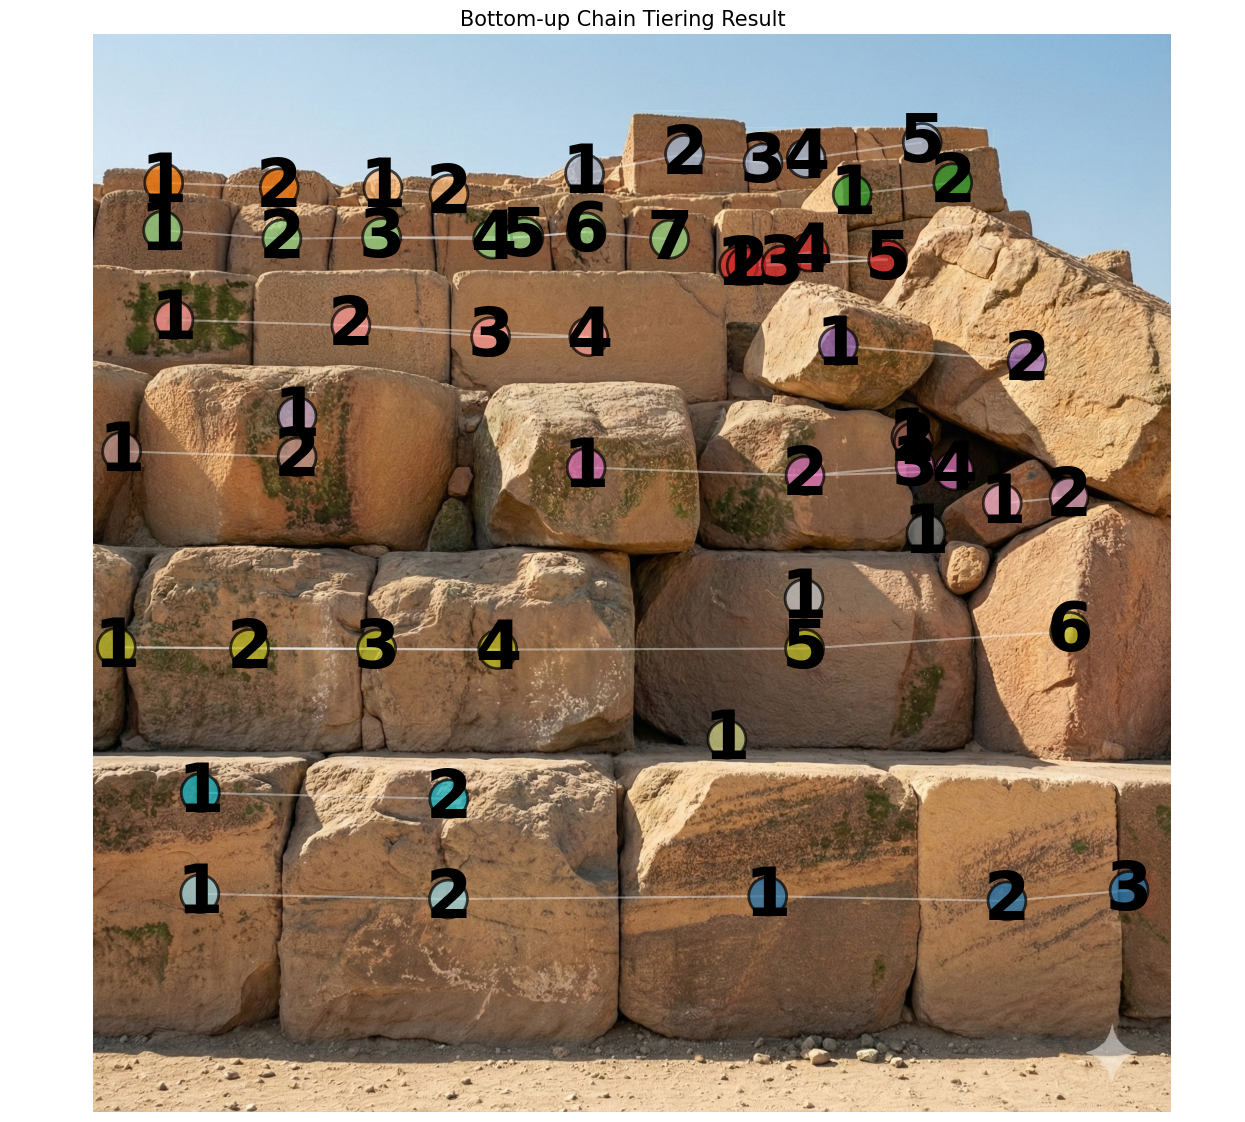

解析結果を pyramid_bottom_up_result.csv に保存しました。
          ピラミッド解析サマリー         
■ 認識された石の総数 : 56 個
■ 認識された総段数   : 20 段
----------------------------------------
■ 各段の石の配列（左から右）
Tier 20 : 4 - 1 - 2
Tier 19 : 5 - 3
Tier 18 : 7 - 6
Tier 17 : 15
Tier 16 : 12 - 10 - 11 - 9 - 8 - 14
Tier 15 : 18
Tier 14 : 13
Tier 13 : 16 - 32
Tier 12 : 23 - 21 - 17 - 19
Tier 11 : 25 - 24
Tier 10 : 22 - 20
Tier  9 : 26
Tier  8 : 27 - 38
Tier  7 : 31 - 30 - 29 - 28
Tier  6 : 37 - 34 - 36 - 35 - 33
Tier  5 : 45 - 41 - 40 - 42 - 43 - 44 - 39
Tier  4 : 50 - 52
Tier  3 : 46 - 47
Tier  2 : 48 - 49
Tier  1 : 51 - 56 - 53 - 54 - 55



In [ ]:
# フェーズ2の実行
if __name__ == "__main__":


    if 'current_masks' in locals() and 'df' in locals() and current_masks is not None:
        
        # 1. ボトムアップ法による推定
        # y_thresholdやdilate_pxはデフォルト定数が使われますが、必要なら引数で上書き可能
        df_final, G_tier = analyze_tiering_bottom_up(df, current_masks)
        
        # 2. 結果の可視化
        img_path = "images/pyramid2_test.jpeg" 
        if os.path.exists(img_path):
            image_rgb = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
            visualize_bottom_up(image_rgb, df_final, G_tier, font_size=24)
            
            # 3. CSV保存
            df_final.to_csv("pyramid_bottom_up_result.csv", index=False)
            print("解析結果を pyramid_bottom_up_result.csv に保存しました。")
        
        # 4. サマリー表示
        print_analysis_summary(df_final)
        
    else:
        print("エラー: フェーズ1が完了していないか、データがありません。#1.2を実行してください。")





In [ ]:
## 参考：旧版のフェーズ2実行　書き方とか使ってる関数結構違うから念の為残しておきます　早いうち比較してみてね
# if __name__ == "__main__":
    if 'current_masks' in locals() and 'df' in locals():
        # 1. 解析の実行（戻り値に G を追加）
        df_final, G_tier = analyze_tiering_bottom_up(df, current_masks, y_threshold=40, dilate_px=10)
        
        # img_path = "images/test_brick.jpg" 
        img_path = "images/pyramid2_test.jpeg"    

        if os.path.exists(img_path):
            image_rgb = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
            fig, ax = plt.subplots(figsize=(20, 14))
            ax.imshow(image_rgb)
            
            # 【追加】同じ段として認識された石同士を白い線（エッジ）で繋ぐ
            pos = nx.get_node_attributes(G_tier, 'pos')
            nx.draw_networkx_edges(G_tier, pos, ax=ax, alpha=0.4, edge_color='white', width=1.5)
            
            # 各石のラベル描画
            font_size = 24 
            for _, row in df_final.iterrows():
                color = plt.cm.tab20(int(row['Tier']) % 20)
                circle = plt.Circle((row['Centroid_X'], row['Centroid_Y']), font_size * 0.8, 
                                    color=color, ec='white', lw=1.5, alpha=0.8, zorder=5)
                ax.add_patch(circle)
                ax.text(row['Centroid_X'], row['Centroid_Y'], str(int(row['Horizontal_Rank'])), 
                        color='white', ha='center', va='center', 
                        fontsize=font_size, fontweight='bold', zorder=6)

            plt.title(f"Bottom-up Tiering with Adjacency Edges", fontsize=22)
            plt.axis('off'); plt.show()
            
            # 結果を保存
            df_final.to_csv("pyramid_bottom_up_result.csv", index=False)
            print("解析結果を pyramid_bottom_up_result.csv に保存しました。")